In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import  LogisticRegression

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import joblib

In [16]:
estudiantes= pd.read_csv('../limpios/estudiantes_clasificacion.csv', index_col=0)
estudiantes.head(5)

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado,tiene_tutor_No,tiene_tutor_Sí
0,0.331561,0.269009,0.833002,0.445949,0.636364,0.5,0.463128,1.000000,0.777143,1.0,0.0,1.0
1,0.418439,0.726082,0.793121,0.102807,0.000000,0.0,0.463128,0.000000,0.600000,1.0,1.0,0.0
2,0.146282,0.862624,0.682795,0.625874,0.636364,0.5,0.561063,1.000000,0.714286,1.0,1.0,0.0
3,0.235301,0.741118,0.785623,0.765471,0.454545,0.5,1.000000,0.465920,0.688571,1.0,1.0,0.0
4,0.000000,0.517917,0.431749,0.445307,0.272727,1.0,1.000000,0.758538,0.514286,1.0,1.0,0.0


Separacion de los datos para entreno y test

In [17]:
tv= 'aprobado'

X=estudiantes.drop(columns=[tv])
y= estudiantes[tv]

In [18]:
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")

Tamaño del conjunto de entrenamiento: (800, 11)
Tamaño del conjunto de prueba: (200, 11)


### Entrenamiento del modelo

In [19]:
model= LogisticRegression(penalty='l2', C=1.0, max_iter=200)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [20]:
y_pred= model.predict(X_test)

In [21]:
y_prob= model.predict_proba(X_test)[:, 1]

### Validacion del modelo

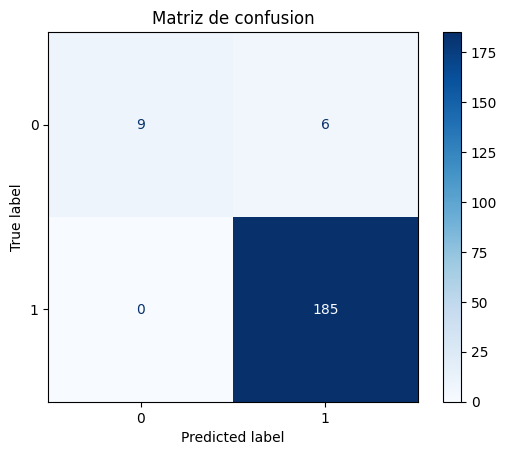

In [22]:
matriz_confusion=confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion)
disp.plot(cmap='Blues')
plt.title('Matriz de confusion')
plt.show()

## Métricas

In [23]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

y_train_probabilidades= model.predict_proba(X_train)
y_test_probabilidades= model.predict_proba(X_test)

In [25]:
metricas = {
    'train': {
        'accuracy': accuracy_score(y_train, y_train_pred),
        'precision': precision_score(y_train, y_train_pred),
        'recall': recall_score(y_train, y_train_pred),
        'F1-score': f1_score(y_train, y_train_pred),
    },
    'test': {
        'accuracy': accuracy_score(y_test, y_test_pred),
        'precision': precision_score(y_test, y_test_pred),
        'recall': recall_score(y_test,y_test_pred),
        'F1-score': f1_score(y_test, y_test_pred),
    },
}

estudiantes_metricas=pd.DataFrame(metricas).T

In [26]:
estudiantes_metricas.round(2)

,accuracy,precision,recall,F1-score
train,0.92,0.92,1.0,0.96
test,0.97,0.97,1.0,0.98


### Cálculos con balanceo

In [ ]:
metricas_balanceadas= {
    'train': {
        'accuracy': accuracy_score(y_train, y_train_pred),
        'precision': precision_score(y_train, y_train_pred),
        'recall': recall_score(y_train, y_train_pred),
        'F1-score': f1_score(y_train, y_train_pred),
    },

    'test': {
        'accuracy': accuracy_score(y_test, y_test_pred),
        'precision': precision_score(y_test, y_test_pred),
        'recall': recall_score(y_test, y_test_pred),
        'F1-score': f1_score(y_test, y_test_pred),
    }
}

estudiantes_metricas_balanceadas= pd.DataFrame(metricas_balanceadas).T

In [ ]:
estudiantes_metricas_balanceadas.round(2)

,accuracy,precision,recall,F1-score
train,0.92,0.92,1.0,0.96
test,0.97,0.97,1.0,0.98


### Importancia de las características

In [ ]:
coeficientes_estudiantes= pd.DataFrame({'Feature': X.columns.to_list(), 'Coefficient':model.coef_[0]})
coeficientes_estudiantes= coeficientes_estudiantes.sort_values(by='Coefficient',ascending=False, key=abs)

In [ ]:
coeficientes_estudiantes.sort_values(by='Coefficient', ascending=False, key=abs)

,Feature,Coefficient
8,nota_final,7.822220
0,horas_estudio_semanal,1.777071
1,nota_anterior,1.408087
2,tasa_asistencia,0.803283
6,horario_estudio_preferido,0.687275
7,estilo_aprendizaje,0.498037
5,nivel_dificultad,0.419570
4,edad,-0.186041
3,horas_sueno,0.178817
9,tiene_tutor_No,-0.036739


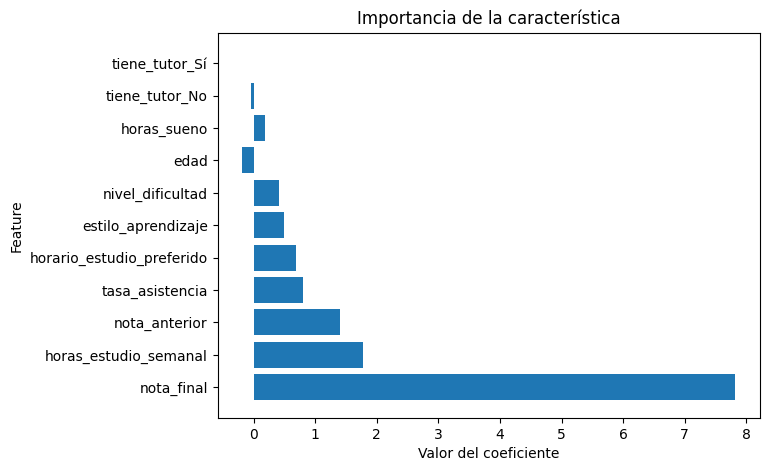

In [ ]:
#Visualizando el gráfico

plt.figure(figsize=(7,5))
plt.barh(coeficientes_estudiantes['Feature'], coeficientes_estudiantes['Coefficient'])
plt.xlabel ('Valor del coeficiente')
plt.ylabel('Feature')
plt.title('Importancia de la característica')
plt.show()


### Entrenamiento final

In [ ]:
modelo_final= LogisticRegression(penalty='l2', C=0.1, max_iter=200, n_jobs=-1)
modelo_final.fit(X,y)

joblib.dump(modelo_final, 'modelo_calificacion.pkl')

['modelo_calificacion.pkl']

In [ ]:
# Definir modelos de regresión logística con regularización
models = {
    "Logistic (L2 - Ridge)": LogisticRegression(penalty='l2', C=1.0, solver='liblinear'),
    "Logistic (L1 - Lasso)": LogisticRegression(penalty='l1', C=0.1, solver='liblinear'),
    "Logistic (ElasticNet)": LogisticRegression(penalty='elasticnet', C=0.1, l1_ratio=0.5, solver='saga'),
}

# Inicializar diccionario para métricas
metrics_results = {}

# Entrenar y evaluar cada modelo
for name, model in models.items():
    model.fit(X_train, y_train)  # Entrenar el modelo

    # Predecir en entrenamiento y prueba
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calcular métricas ponderadas
    metrics_results[name] = {
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Train Precision (Weighted)": precision_score(y_train, y_train_pred, average='weighted',zero_division=0),
        "Train Recall (Weighted)": recall_score(y_train, y_train_pred, average='weighted',zero_division=0),
        "Train F1 (Weighted)": f1_score(y_train, y_train_pred, average='weighted',zero_division=0),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Test Precision (Weighted)": precision_score(y_test, y_test_pred, average='weighted',zero_division=0),
        "Test Recall (Weighted)": recall_score(y_test, y_test_pred, average='weighted',zero_division=0),
        "Test F1 (Weighted)": f1_score(y_test, y_test_pred, average='weighted',zero_division=0),
    }

# Convertir métricas a DataFrame
estudiantes_metricas = pd.DataFrame(metrics_results).T

In [ ]:
estudiantes_metricas.round(2)

,Train Accuracy,Train Precision (Weighted),Train Recall (Weighted),Train F1 (Weighted),Test Accuracy,Test Precision (Weighted),Test Recall (Weighted),Test F1 (Weighted)
Logistic (L2 - Ridge),0.92,0.92,0.92,0.89,0.96,0.96,0.96,0.95
Logistic (L1 - Lasso),0.89,0.90,0.89,0.84,0.92,0.86,0.92,0.89
Logistic (ElasticNet),0.89,0.79,0.89,0.84,0.92,0.86,0.92,0.89
